# Определение языка текста на основе машинного обучения

Этот блокнот Jupyter содержит пошаговое выполнение исследования и разработки классификатора естественных языков.

### Содержание:
1. **Шаг 1**: Анализ полей и структуры датасета. Обоснование выбора и исключения данных.
2. **Шаг 2**: Предварительная обработка текстов (очистка, лемматизация/стемминг, удаление стоп-слов).
3. **Шаг 3**: Тематическое моделирование (Word Clouds, LDA) для каждого языка.
4. **Шаг 4**: Векторизация текстовых данных (Сравнение TF-IDF по словам и символам).
5. **Шаг 5**: Обучение классификаторов (Naive Bayes, Logistic Regression, LinearSVC), оценка качества.
6. **Шаг 6**: Парсинг текстовых данных (симуляция) и реализация цикла бутстраппинга (Active Learning).

In [1]:
import os
import re
import csv
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
import pymorphy3
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import LatentDirichletAllocation
from wordcloud import WordCloud

# Загрузка ресурсов NLTK
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

c:\Users\000\Documents\AnotherGroup\.venv\Lib\site-packages\nltk\downloader.py:980: RuntimeWarning: Security Violation [pathsec.urlopen]: SSRF attempt to restricted IP 198.18.0.138
  ElementTree.parse(urlopen(self._url)).getroot()


True

## Шаг 1. Анализ структуры набора данных и признаков

Загрузим датасет `TextLanguage.csv` и проанализируем распределение классов и длину текстов. Также приведем обоснование выбора признаков и исключения строк.

In [2]:
# Загрузка датасета
df = pd.read_csv('TextLanguage.csv')
print("Размер исходного датасета:", df.shape)
print("\nПервые 5 строк:")
print(df.head())

# Распределение по языкам
class_counts = df['Language'].value_counts()
print("\nРаспределение по классам (языкам):")
print(class_counts)

# Проверка на пропущенные значения
print("\nКоличество пустых значений:")
print(df.isnull().sum())

Размер исходного датасета: (10337, 2)

Первые 5 строк:
                                                Text Language
0   Nature, in the broadest sense, is the natural...  English
1  "Nature" can refer to the phenomena of the phy...  English
2  The study of nature is a large, if not the onl...  English
3  Although humans are part of nature, human acti...  English
4  [1] The word nature is borrowed from the Old F...  English

Распределение по классам (языкам):
Language
English       1385
French        1014
Spanish        819
Portugeese     739
Italian        698
Russian        692
Sweedish       676
Malayalam      594
Dutch          546
Arabic         536
Turkish        474
German         470
Tamil          469
Danish         428
Kannada        369
Greek          365
Hindi           63
Name: count, dtype: int64

Количество пустых значений:
Text        0
Language    0
dtype: int64


Статистика длины текстов по языкам (в символах):
            count         mean  min    max
Language                                  
Arabic        536    99.192164    1    581
Danish        428    91.252336    3    737
Dutch         546    99.263736    7    759
English      1385   136.901083    5    720
French       1014   145.135108    5   1168
German        470    74.702128    6    455
Greek         365   106.260274    5    733
Hindi          63  1209.190476   15  19088
Italian       698   142.157593    4   1007
Kannada       369    87.696477    5    443
Malayalam     594    99.735690    5    479
Portugeese    739   139.261164    5   1965
Russian       692   112.121387    3    625
Spanish       819   130.174603    6    618
Sweedish      676   118.230769    4    769
Tamil         469   105.078891    3    499
Turkish       474    88.487342    5    478


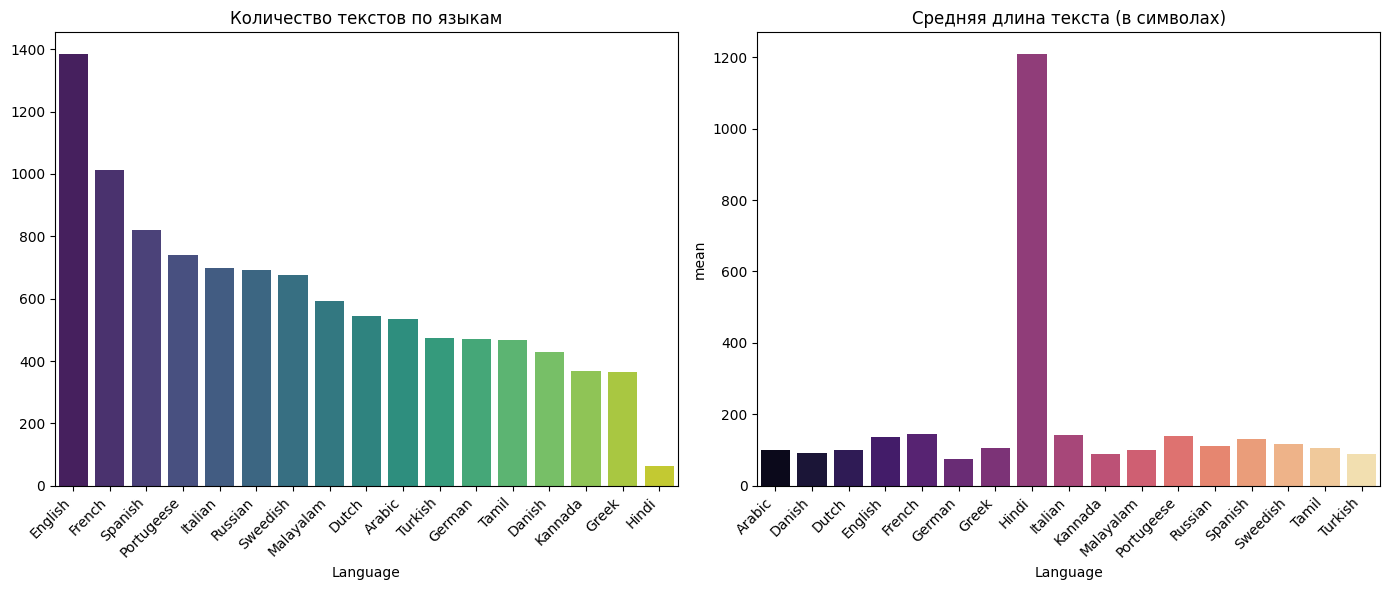

In [3]:
# Анализ длины текстов
df['char_len'] = df['Text'].astype(str).apply(len)
df['word_len'] = df['Text'].astype(str).apply(lambda x: len(x.split()))

print("Статистика длины текстов по языкам (в символах):")
stats = df.groupby('Language')['char_len'].agg(['count', 'mean', 'min', 'max'])
print(stats)

# Построение графиков распределения
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.barplot(x=class_counts.index, y=class_counts.values, hue=class_counts.index, palette='viridis', legend=False)
plt.title("Количество текстов по языкам")
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 2, 2)
sns.barplot(x=stats.index, y=stats['mean'], hue=stats.index, palette='magma', legend=False)
plt.title("Средняя длина текста (в символах)")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('dataset_stats.png', dpi=300)
plt.show()

### Обоснование выбора и исключения данных

1. **Структура**: Датасет содержит входное поле `Text` (текст на одном из 17 языков) и целевую метку `Language`.
2. **Влияние признаков**:
   - **Символьные n-граммы** являются ключевым атрибутом. Для определения языка важно улавливать характерные буквосочетания, окончания и диакритические знаки (например, `ü`, `ö`, `ß` в немецком, `ñ` и `¿` в испанском, кириллица в русском). Символьные n-граммы размером от 2 до 4 символов отлично решают эту задачу, стабильны к опечаткам и эффективно работают на коротких фразах.
   - **Стоп-слова** (такие как `the`, `and` в английском, `и`, `в`, `на` в русском) служат четкими идентификаторами.
   - **Специфические алфавиты** (например, деванагари для хинди, тамильское, каннада или малаяламское письмо) однозначно идентифицируют соответствующие восточные языки.
3. **Исключение данных**: Мы удалим:
   - Дубликаты текстов (предотвращает утечку данных при кросс-валидации).
   - Строки с пустым текстом.
   - Тексты короче 3 символов (в них нет достаточного языкового контекста).
   - Строки, состоящие только из цифр.

In [4]:
# Очистка данных
initial_len = len(df)
df = df.dropna(subset=['Text'])
df = df.drop_duplicates(subset=['Text'])
df = df[df['char_len'] >= 3]
df = df[~df['Text'].astype(str).str.match(r'^\d+$')]

print(f"Удалено невалидных строк и дубликатов: {initial_len - len(df)}")
print(f"Итоговый размер датасета для обучения: {len(df)}")

Удалено невалидных строк и дубликатов: 71
Итоговый размер датасета для обучения: 10266


## Шаг 2. Предварительная обработка текстов

Разработаем функцию для предобработки текстов:
1. Перевод в нижний регистр.
2. Очистка от HTML-тегов, лишних пробелов, спецсимволов и цифр.
3. Очистка от стоп-слов (включая расширенный список неинформативных слов для повышения качества).
4. Двойная предобработка: сохранение окончаний для визуализации (clean_text, с pymorphy3 лемматизацией для русского) и стемминг/лемматизация для обучения моделей (stemmed_text).

In [5]:

# Сопоставление имен языков с ресурсами стоп-слов NLTK
nltk_lang_map = {
    'English': 'english', 'Russian': 'russian', 'Spanish': 'spanish',
    'Portugeese': 'portuguese', 'Italian': 'italian', 'French': 'french',
    'Dutch': 'dutch', 'German': 'german', 'Danish': 'danish',
    'Sweedish': 'swedish', 'Arabic': 'arabic', 'Turkish': 'turkish',
    'Greek': 'greek'
}

custom_stopwords = {
    'English': {'wikipedia', 'article', 'articles', 'page', 'pages', 'one', 'two', 'many', 'also', 'would', 'like', 'get', 'use', 'used', 'using', 'first', 'new', 'well', 'may'},
    'Russian': {'это', 'также', 'например', 'года', 'году', 'могут', 'является', 'быть', 'время', 'однако', 'очень', 'просто', 'могу', 'сказать', 'можете', 'своей', 'который', 'которые', 'которая', 'которого', 'наш', 'хочу', 'даже', 'слово', 'слова'},
    'Spanish': {'wikipedia', 'artículo', 'artículos', 'si', 'bien', 'puede', 'ser', 'solo', 'así', 'cada', 'dos', 'hacer', 'tener', 'como', 'más', 'pero', 'todo', 'también'},
    'German': {'wikipedia', 'artikel', 'hast', 'kannst', 'gut', 'wäre', 'oh', 'tut', 'sagen', 'sehen', 'wirklich', 'jemand', 'mehr', 'immer', 'schon', 'mal', 'gibt'},
    'Arabic': {'يكيبيديا', 'ويكيبيديا', 'صفحة', 'صفحات', 'أنه', 'يمكن', 'خلال', 'تلك', 'حيث', 'عندما', 'أيضا', 'حتى', 'تم', 'كانت', 'يكون'}
}

stop_words_dict = {}
for lang, nltk_name in nltk_lang_map.items():
    try:
        stops = set(stopwords.words(nltk_name))
    except:
        stops = set()
    if lang in custom_stopwords:
        stops.update(custom_stopwords[lang])
    stop_words_dict[lang] = stops

morph = pymorphy3.MorphAnalyzer()
pymorphy_cache = {}

def lemmatize_russian(word):
    if word not in pymorphy_cache:
        pymorphy_cache[word] = morph.parse(word)[0].normal_form
    return pymorphy_cache[word]

stemmers = {}
for lang_name, nltk_name in [
    ('English', 'english'),
    ('Spanish', 'spanish'),
    ('Portugeese', 'portuguese'),
    ('Italian', 'italian'),
    ('French', 'french'),
    ('Dutch', 'dutch'),
    ('German', 'german'),
    ('Danish', 'danish'),
    ('Sweedish', 'swedish'),
    ('Arabic', 'arabic')
]:
    try:
        stemmers[lang_name] = SnowballStemmer(nltk_name)
    except Exception as e:
        pass

def preprocess_text(text, language, stem=False):
    text = str(text).lower()
    # Удаление HTML тегов
    text = re.sub(r'<[^>]+>', ' ', text)
    
    # Очистка в зависимости от письменности языка
    if language == 'Russian':
        text = re.sub(r'[^а-яё\s]', ' ', text)
    elif language == 'Arabic':
        text = re.sub(r'[^\u0600-\u06FF\s]', ' ', text)
    elif language == 'Greek':
        text = re.sub(r'[^\u0370-\u03FF\s]', ' ', text)
    elif language == 'Hindi':
        text = re.sub(r'[^\u0900-\u097F\s]', ' ', text)
    elif language == 'Tamil':
        text = re.sub(r'[^\u0B80-\u0BFF\s]', ' ', text)
    elif language == 'Kannada':
        text = re.sub(r'[^\u0C80-\u0CFF\s]', ' ', text)
    elif language == 'Malayalam':
        text = re.sub(r'[^\u0D00-\u0D7F\s]', ' ', text)
    else:
        # Для латинских языков сохраняем буквы и умлауты/акценты
        text = re.sub(r'[^a-zà-ÿœæ\s]', ' ', text)
        
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    
    # Удаление стоп-слов
    lang_stops = stop_words_dict.get(language, set())
    words = [w for w in words if w not in lang_stops]
    
    if stem:
        if language == 'Russian':
            words = [lemmatize_russian(w) for w in words]
        elif language in stemmers:
            words = [stemmers[language].stem(w) for w in words]
    else:
        if language == 'Russian':
            words = [lemmatize_russian(w) for w in words]
            
    return ' '.join(words)

print("Предобработка текстов...")
df['clean_text'] = df.apply(lambda row: preprocess_text(row['Text'], row['Language'], stem=False), axis=1)
df['stemmed_text'] = df.apply(lambda row: preprocess_text(row['Text'], row['Language'], stem=True), axis=1)
# Удаляем пустые после очистки тексты
df = df[(df['clean_text'].str.strip() != '') & (df['stemmed_text'].str.strip() != '')]
print("Предобработка завершена. Размер обучающей выборки:", df.shape[0])

Предобработка текстов...
Предобработка завершена. Размер обучающей выборки: 10219


## Шаг 3. Тематическое моделирование и визуализация

Построим облака слов для основных языков и извлечем ключевые темы с помощью тематического моделирования LDA.

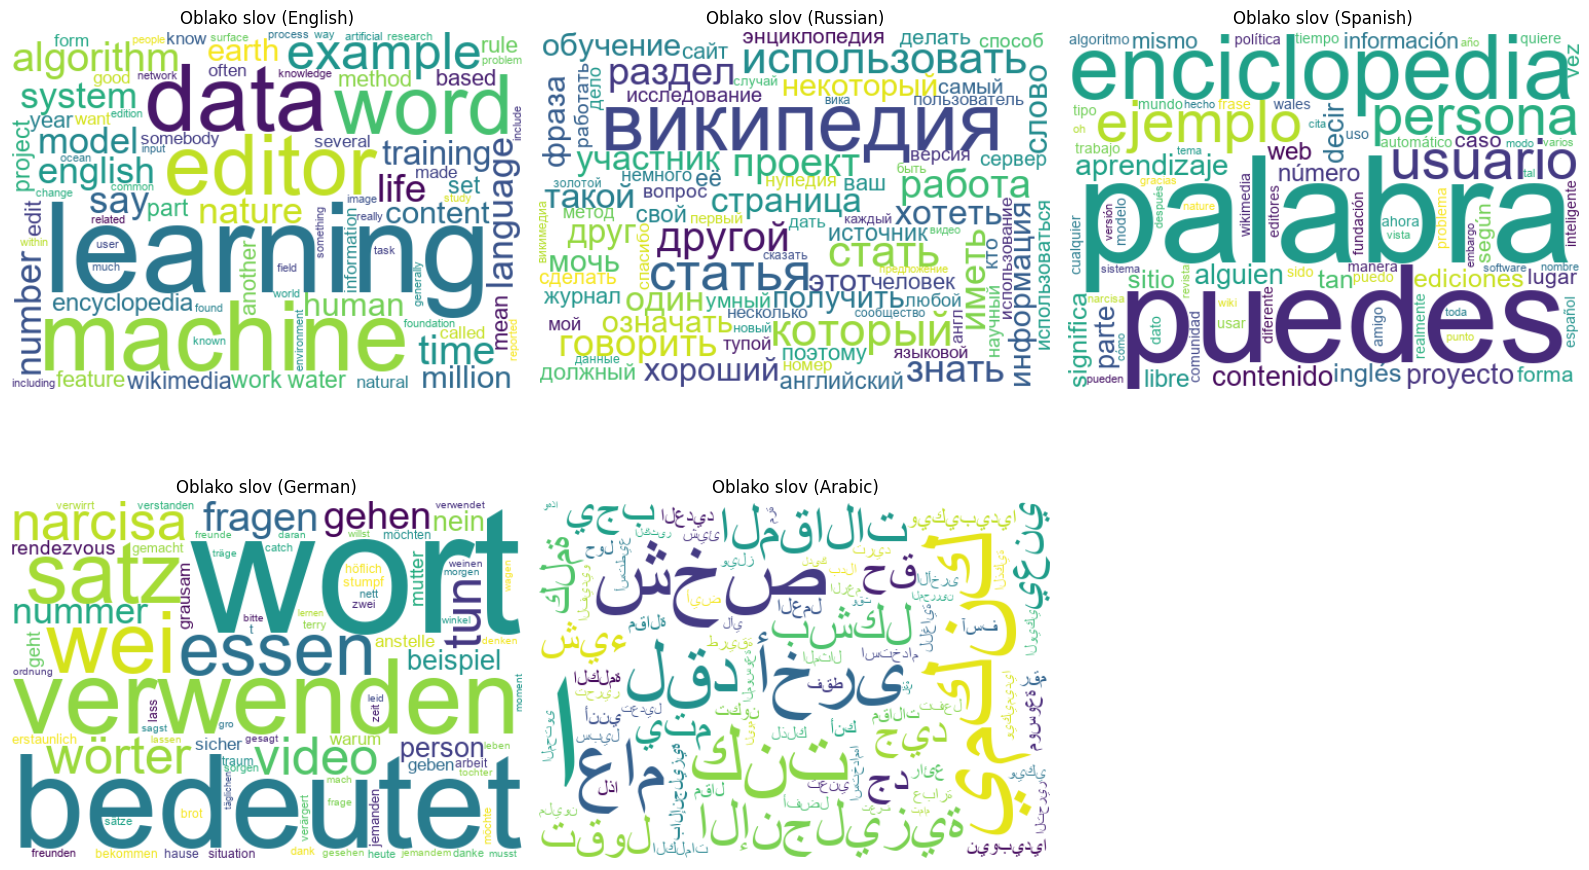

In [6]:
# Облака слов для популярных языков
langs_show = ['English', 'Russian', 'Spanish', 'German', 'Arabic']
plt.figure(figsize=(16, 10))
for i, lang in enumerate(langs_show):
    lang_text = ' '.join(df[df['Language'] == lang]['clean_text'].astype(str))
    wc = WordCloud(font_path='arial.ttf', width=500, height=350, background_color='white', max_words=80, collocations=False).generate(lang_text)
    
    plt.subplot(2, 3, i+1)
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f"Oblako slov ({lang})")
    plt.axis('off')

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=300)
plt.show()

In [7]:
# Тематическое моделирование LDA для выбранных языков
print("Ключевые слова по темам (LDA):")
for lang in langs_show:
    lang_df = df[df['Language'] == lang]
    if len(lang_df) < 5:
        continue
        
    lda_vectorizer = TfidfVectorizer(max_features=400)
    dtm = lda_vectorizer.fit_transform(lang_df['clean_text'])
    
    lda_model = LatentDirichletAllocation(n_components=2, random_state=42)
    lda_model.fit(dtm)
    topic_distributions = lda_model.transform(dtm)
    
    print(f"\nЯзык: {lang}")
    terms = lda_vectorizer.get_feature_names_out()
    for t_idx, topic in enumerate(lda_model.components_):
        top_terms = [terms[i] for i in topic.argsort()[:-6:-1]]
        print(f"  Тема #{t_idx+1}: {', '.join(top_terms)}")
        top_doc_indices = topic_distributions[:, t_idx].argsort()[::-1][:3]
        print("    Примеры текстов:")
        for doc_idx in top_doc_indices:
            example_text = lang_df.iloc[doc_idx]['Text']
            if len(example_text) > 100:
                example_text = example_text[:100] + '...'
            print(f"      - {example_text}")

Ключевые слова по темам (LDA):

Язык: English
  Тема #1: say, editors, english, language, content
    Примеры текстов:
      - The Economist reported that the number of contributors with an average of five or more edits per mon...
      - He described it as "a work of reference as useful as any in existence", with so wide a range that it...
      - [134][135][136] Jimmy Wales has described Wikipedia as "an effort to create and distribute a free en...
  Тема #2: learning, machine, data, life, time
    Примеры текстов:
      - Machine learning algorithms build a model based on sample data, known as "training data", in order t...
      - Although Earth is the only body within the solar system known to support life, evidence suggests tha...
      - [30] Machine learning and data mining often employ the same methods and overlap significantly, but w...

Язык: Russian
  Тема #1: знать, говорить, мочь, хотеть, хороший
    Примеры текстов:
      - приготовилась ко сну, мама, я действительно над

## Шаг 4. Векторизация текстовых данных

Сравним две стратегии векторизации: на уровне слов и на уровне символьных n-грамм.

In [8]:
# Разделение выборки: рабочий корпус включает весь исходный датасет
corpus_df = df.copy()
print(f"Размер рабочего корпуса: {corpus_df.shape[0]}")

# Парсинг данных с Википедии (500 текстов на каждом языке) для симуляции активного обучения
import os
import time
output_filename = 'scraped_raw.csv'
if not os.path.exists(output_filename):
    print('Файл scraped_raw.csv не найден. Запуск парсинга с Википедии...')
    import urllib.request
    try:
        urllib.request.urlopen('https://en.wikipedia.org', timeout=2)
        offline_mode = False
    except Exception:
        offline_mode = True
        print('Wikipedia API недоступен (оффлайн режим). Используем симуляцию на локальных данных.')

    if offline_mode:
        class MockPage:
            def __init__(self, title, content):
                self.title = title
                self.content = content
        class MockWikipedia:
            def __init__(self):
                self.df = pd.read_csv('TextLanguage.csv')
                self.code_to_lang = {
                    'en': 'English', 'fr': 'French', 'es': 'Spanish',
                    'pt': 'Portugeese', 'it': 'Italian', 'ru': 'Russian',
                    'sv': 'Sweedish', 'ml': 'Malayalam', 'nl': 'Dutch',
                    'ar': 'Arabic', 'tr': 'Turkish', 'de': 'German',
                    'ta': 'Tamil', 'da': 'Danish', 'kn': 'Kannada',
                    'el': 'Greek', 'hi': 'Hindi'
                }
                self.current_lang = 'English'
            def set_lang(self, code):
                self.current_lang = self.code_to_lang.get(code, 'English')
            def random(self, pages=5):
                return [f'Mock_Page_{self.current_lang}_{i}' for i in range(pages)]
            def page(self, title, auto_suggest=False):
                lang_texts = self.df[self.df['Language'] == self.current_lang]['Text'].dropna().tolist()
                if not lang_texts:
                    lang_texts = ['Mock text']
                import random
                random.seed(title)
                selected = random.choices(lang_texts, k=min(15, len(lang_texts)))
                return MockPage(title, '\n\n'.join(selected))
            @property
            def exceptions(self):
                import wikipedia
                return wikipedia.exceptions
        wikipedia = MockWikipedia()
    else:
        import wikipedia

    dataset_stats = {
        'English': {'code': 'en'},
        'French': {'code': 'fr'},
        'Spanish': {'code': 'es'},
        'Portugeese': {'code': 'pt'},
        'Italian': {'code': 'it'},
        'Russian': {'code': 'ru'},
        'Sweedish': {'code': 'sv'},
        'Malayalam': {'code': 'ml'},
        'Dutch': {'code': 'nl'},
        'Arabic': {'code': 'ar'},
        'Turkish': {'code': 'tr'},
        'German': {'code': 'de'},
        'Tamil': {'code': 'ta'},
        'Danish': {'code': 'da'},
        'Kannada': {'code': 'kn'},
        'Greek': {'code': 'el'},
        'Hindi': {'code': 'hi'}
    }
    TARGET_COUNT = 500
    MIN_TEXT_LENGTH = 50
    augmented_data = []
    print('Начинаем сбор данных из Википедии...')
    for lang_name, info in dataset_stats.items():
        code = info['code']
        wikipedia.set_lang(code)
        collected_for_lang = 0
        retries = 0
        while collected_for_lang < TARGET_COUNT and retries < 150:
            try:
                random_titles = wikipedia.random(pages=5)
                if isinstance(random_titles, str):
                    random_titles = [random_titles]
                for title in random_titles:
                    if collected_for_lang >= TARGET_COUNT:
                        break
                    try:
                        page = wikipedia.page(title, auto_suggest=False)
                        paragraphs = page.content.split('\n')
                        for paragraph in paragraphs:
                            clean_text = paragraph.strip()
                            if len(clean_text) > MIN_TEXT_LENGTH and not clean_text.startswith('=='):
                                augmented_data.append({
                                    'Language': lang_name,
                                    'Text': clean_text
                                })
                                collected_for_lang += 1
                                if collected_for_lang >= TARGET_COUNT:
                                    break
                        time.sleep(0.01)
                    except wikipedia.exceptions.DisambiguationError:
                        continue
                    except wikipedia.exceptions.PageError:
                        continue
                    except Exception:
                        continue
            except Exception as e:
                time.sleep(1)
                retries += 1
        print(f'[{lang_name}] Успешно собрано {collected_for_lang} строк.')
    df_new = pd.DataFrame(augmented_data)
    df_new.to_csv(output_filename, index=False, encoding='utf-8')
else:
    print(f'Загрузка предварительно собранного пула из {output_filename}...')

scraped_df = pd.read_csv(output_filename)
print('Предобработка пула с Википедии...')
scraped_df['clean_text'] = scraped_df.apply(lambda row: preprocess_text(row['Text'], row['Language'], stem=False), axis=1)
scraped_df['stemmed_text'] = scraped_df.apply(lambda row: preprocess_text(row['Text'], row['Language'], stem=True), axis=1)
scraped_df = scraped_df[(scraped_df['clean_text'].str.strip() != '') & (scraped_df['stemmed_text'].str.strip() != '')]
print(f'Размер пула парсинга после предобработки: {scraped_df.shape[0]}')

# Разделение рабочего корпуса на обучающую и тестовую
X_train, X_test, y_train, y_test = train_test_split(
    corpus_df['stemmed_text'], corpus_df['Language'], test_size=0.2, random_state=42, stratify=corpus_df['Language']
)

# Словарный TF-IDF
word_vec = TfidfVectorizer(analyzer='word', ngram_range=(1, 2), max_features=15000)
X_train_w = word_vec.fit_transform(X_train)
X_test_w = word_vec.transform(X_test)

# Символьный TF-IDF
char_vec = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4), max_features=25000)
X_train_c = char_vec.fit_transform(X_train)
X_test_c = char_vec.transform(X_test)

# Быстрая оценка на Naive Bayes
nb = MultinomialNB()

nb.fit(X_train_w, y_train)
w_acc = accuracy_score(y_test, nb.predict(X_test_w))

nb.fit(X_train_c, y_train)
c_acc = accuracy_score(y_test, nb.predict(X_test_c))

print(f"Точность с векторизацией по словам: {w_acc:.4f}")
print(f"Точность с векторизацией по символам (n-граммы 2-4): {c_acc:.4f}")

Размер рабочего корпуса: 10219
Загрузка предварительно собранного пула из scraped_raw.csv...
Предобработка пула с Википедии...
Размер пула парсинга после предобработки: 8500
Точность с векторизацией по словам: 0.9193
Точность с векторизацией по символам (n-граммы 2-4): 0.8865


## Шаг 5. Обучение базовых моделей классификации и их оценка

Обучим три базовые модели на исходном датасете:
1. Multinomial Naive Bayes
2. Logistic Regression
3. Linear Support Vector Classification (LinearSVC) с калибровкой вероятностей

Сравним их точность на валидационной выборке и проверим качество классификации на тестовых фразах.

In [9]:
base_models = {
    'Multinomial Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Linear SVC': CalibratedClassifierCV(estimator=LinearSVC(random_state=42))
}

base_results = {}
for name, model in base_models.items():
    print(f"Обучение модели {name}...")
    model.fit(X_train_c, y_train)
    preds = model.predict(X_test_c)
    acc = accuracy_score(y_test, preds)
    base_results[name] = {
        'model': model,
        'accuracy': acc,
        'preds': preds
    }
    print(f"  {name} Baseline Accuracy: {acc:.4f}")

best_base_name = max(base_results, key=lambda k: base_results[k]['accuracy'])
print(f"\nЛучшая модель на первом этапе: {best_base_name}")

print("\nДетальный отчет для лучшей базовой модели:")
print(classification_report(y_test, base_results[best_base_name]['preds']))

# Тестирование предсказаний лучшей базовой модели
sample_phrases = [
    ("This is a simple test sentence to verify baseline classifier performance.", "English"),
    ("Привет, это тестовая строка для проверки работы нашего базового классификатора.", "Russian"),
    ("Hola, esto es una simple frase de prueba para comprobar la classificação.", "Spanish"),
    ("Dies ist ein einfacher Testfall, um das Modell zu überprüfen.", "German"),
    ("هذه جملة تجريبية بسيطة للتحقق من أداء النموذج.", "Arabic")
]
print("\nПроверка классификации тестовых текстов:")
baseline_pipeline = Pipeline([
    ('vectorizer', char_vec),
    ('classifier', base_results[best_base_name]['model'])
])

for text, true_lang in sample_phrases:
    cyrillic_chars = len(re.findall(r'[а-яА-ЯёЁ]', text))
    arabic_chars = len(re.findall(r'[\u0600-\u06FF]', text))
    guessed_group = 'Latin'
    if cyrillic_chars > 2:
        guessed_group = 'Russian'
    elif arabic_chars > 2:
        guessed_group = 'Arabic'
        
    cleaned_sample = preprocess_text(text, guessed_group, stem=True)
    probs = baseline_pipeline.predict_proba([cleaned_sample])[0]
    classes = baseline_pipeline.classes_
    pred_idx = np.argmax(probs)
    pred_lang = classes[pred_idx]
    confidence = probs[pred_idx]
    print(f"Текст: '{text[:50]}...' -> Прогноз: {pred_lang} (Уверенность: {confidence:.2%}), Факт: {true_lang}")

Обучение модели Multinomial Naive Bayes...
  Multinomial Naive Bayes Baseline Accuracy: 0.8865
Обучение модели Logistic Regression...
  Logistic Regression Baseline Accuracy: 0.9565
Обучение модели Linear SVC...
  Linear SVC Baseline Accuracy: 0.9633

Лучшая модель на первом этапе: Linear SVC

Детальный отчет для лучшей базовой модели:
              precision    recall  f1-score   support

      Arabic       1.00      1.00      1.00       106
      Danish       0.92      0.85      0.88        84
       Dutch       0.94      0.96      0.95       108
     English       0.98      0.97      0.97       275
      French       0.95      0.97      0.96       201
      German       0.90      0.95      0.92        91
       Greek       1.00      1.00      1.00        72
       Hindi       1.00      1.00      1.00        12
     Italian       0.96      0.93      0.94       138
     Kannada       1.00      1.00      1.00        73
   Malayalam       1.00      1.00      1.00       118
  Portugeese 

## Шаг 6. Active Learning Loop (Bootstrapping)

Реализуем итеративный цикл активного обучения. На каждой итерации текущая модель предсказывает вероятности для неразмеченных данных (спарсенных с Википедии). Тексты, в которых модель уверена (вероятность > 0.8) или абсолютно не уверена (вероятность < 0.2), добавляются в обучающий корпус, после чего модель переобучается.

In [11]:
df_augmented = corpus_df.copy()
unique_languages = df_augmented['Language'].unique()

scraped_df = pd.DataFrame()
if 'output_filename' in locals() and os.path.exists(output_filename):
    try:
        scraped_df = pd.read_csv(output_filename)
        scraped_df['clean_text'] = scraped_df.apply(lambda row: preprocess_text(row['Text'], row['Language'], stem=False), axis=1)
        scraped_df['stemmed_text'] = scraped_df.apply(lambda row: preprocess_text(row['Text'], row['Language'], stem=True), axis=1)
        scraped_df = scraped_df[(scraped_df['clean_text'].str.strip() != '') & (scraped_df['stemmed_text'].str.strip() != '')]
    except Exception as e:
        print(f"Ошибка загрузки дополнительных спарсенных данных: {e}")

active_model = CalibratedClassifierCV(estimator=LinearSVC(random_state=42))
active_vectorizer = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4), max_features=25000)

num_iterations = 3
for iteration in range(1, num_iterations + 1):
    print(f"--- Итерация активного обучения {iteration} ---")
    if scraped_df.empty:
        print("Больше нет доступных спарсенных данных. Остановка активного обучения.")
        break
        
    # 1. Train current model
    X_train_act, X_test_act, y_train_act, y_test_act = train_test_split(
        df_augmented['stemmed_text'], df_augmented['Language'], test_size=0.2, random_state=42, stratify=df_augmented['Language']
    )
    X_train_act_vec = active_vectorizer.fit_transform(X_train_act)
    X_test_act_vec = active_vectorizer.transform(X_test_act)
    
    print(f"Обучение на {len(df_augmented)} записях...")
    active_model.fit(X_train_act_vec, y_train_act)
    acc = accuracy_score(y_test_act, active_model.predict(X_test_act_vec))
    print(f"Точность текущей модели: {acc:.4f}")
    
    # 2. Predict on scraped data
    scraped_vec = active_vectorizer.transform(scraped_df['stemmed_text'])
    probs = active_model.predict_proba(scraped_vec)
    max_probs = np.max(probs, axis=1)
    
    # 3. Filter criteria: > 0.8 or < 0.2
    selected_mask = (max_probs > 0.8) | (max_probs < 0.2)
    selected_records = scraped_df[selected_mask].copy()
    
    if selected_records.empty:
        print("Ни один текст не преодолел порог уверенности. Остановка активного обучения.")
        break
        
    print(f"Выбрано {len(selected_records)} текстов для добавления (Уверенность > 0.8 или < 0.2).")
    
    # 4. Add to training corpus and remove from scraped pool
    df_augmented = pd.concat([df_augmented, selected_records], ignore_index=True)
    scraped_df = scraped_df[~selected_mask].copy()


--- Итерация активного обучения 1 ---
Обучение на 10219 записях...
Точность текущей модели: 0.9633
Выбрано 8301 текстов для добавления (Уверенность > 0.8 или < 0.2).
--- Итерация активного обучения 2 ---
Обучение на 18520 записях...
Точность текущей модели: 0.9814
Выбрано 76 текстов для добавления (Уверенность > 0.8 или < 0.2).
--- Итерация активного обучения 3 ---
Обучение на 18596 записях...
Точность текущей модели: 0.9806
Ни один текст не преодолел порог уверенности. Остановка активного обучения.


## Шаг 7. Повторное обучение классификаторов на данных после Bootstrapping

Обучим финальную модель Linear SVC, которая показала себя лучше всего, на обогащенном наборе данных, сохраним финальный пайплайн в `best_model.pkl` и перестроим визуализации.

Обучение финальной лучшей модели (Linear SVC) на полностью расширенном датасете...
Точность финальной модели: 0.9806
--- Краткий анализ финального датасета ---
Language Distribution:
Language
English       1862
French        1505
Spanish       1290
Portugeese    1218
Italian       1192
Russian       1180
Sweedish      1168
Malayalam     1091
Arabic        1029
Dutch         1004
Name: count, dtype: int64


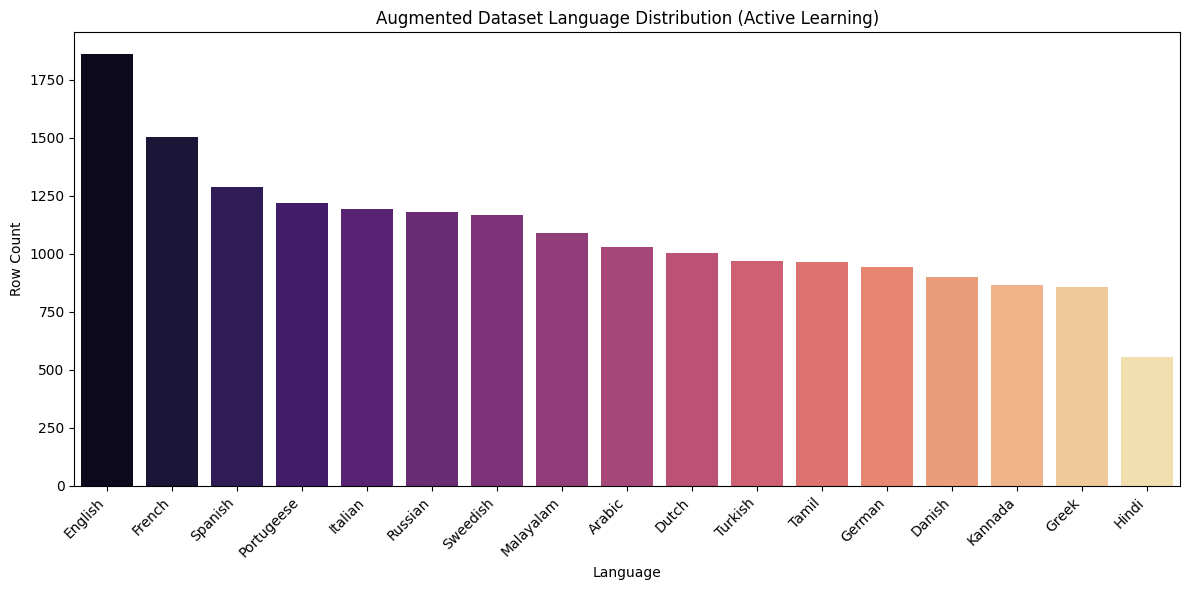

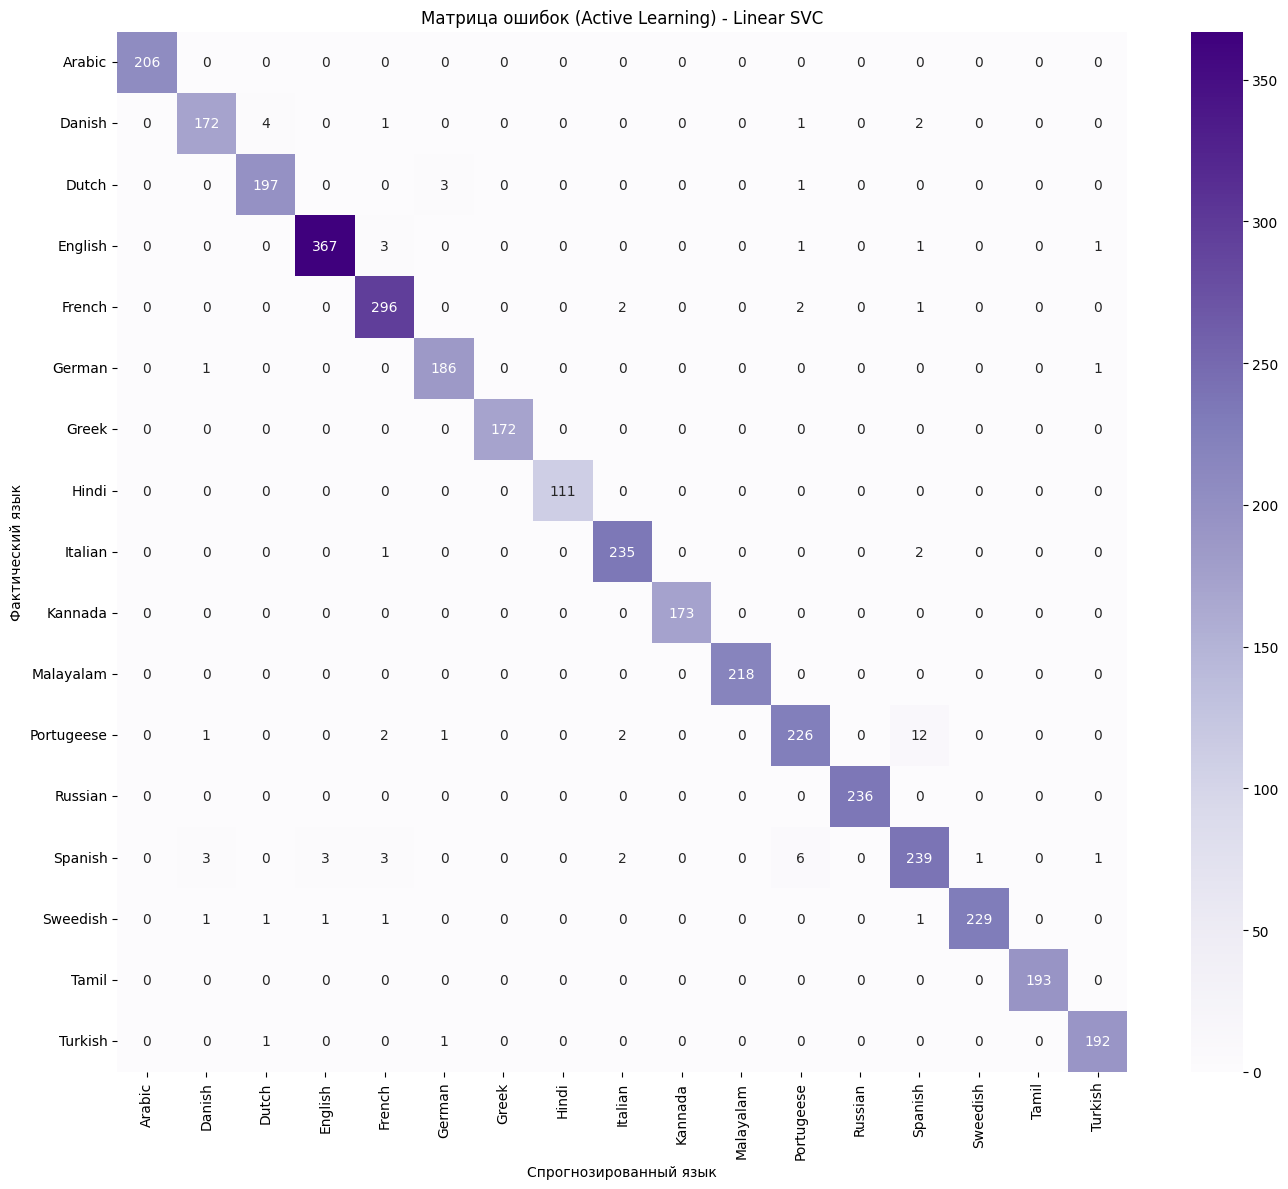

Финальная модель успешно сохранена в best_model.pkl!
Обновление облака слов...


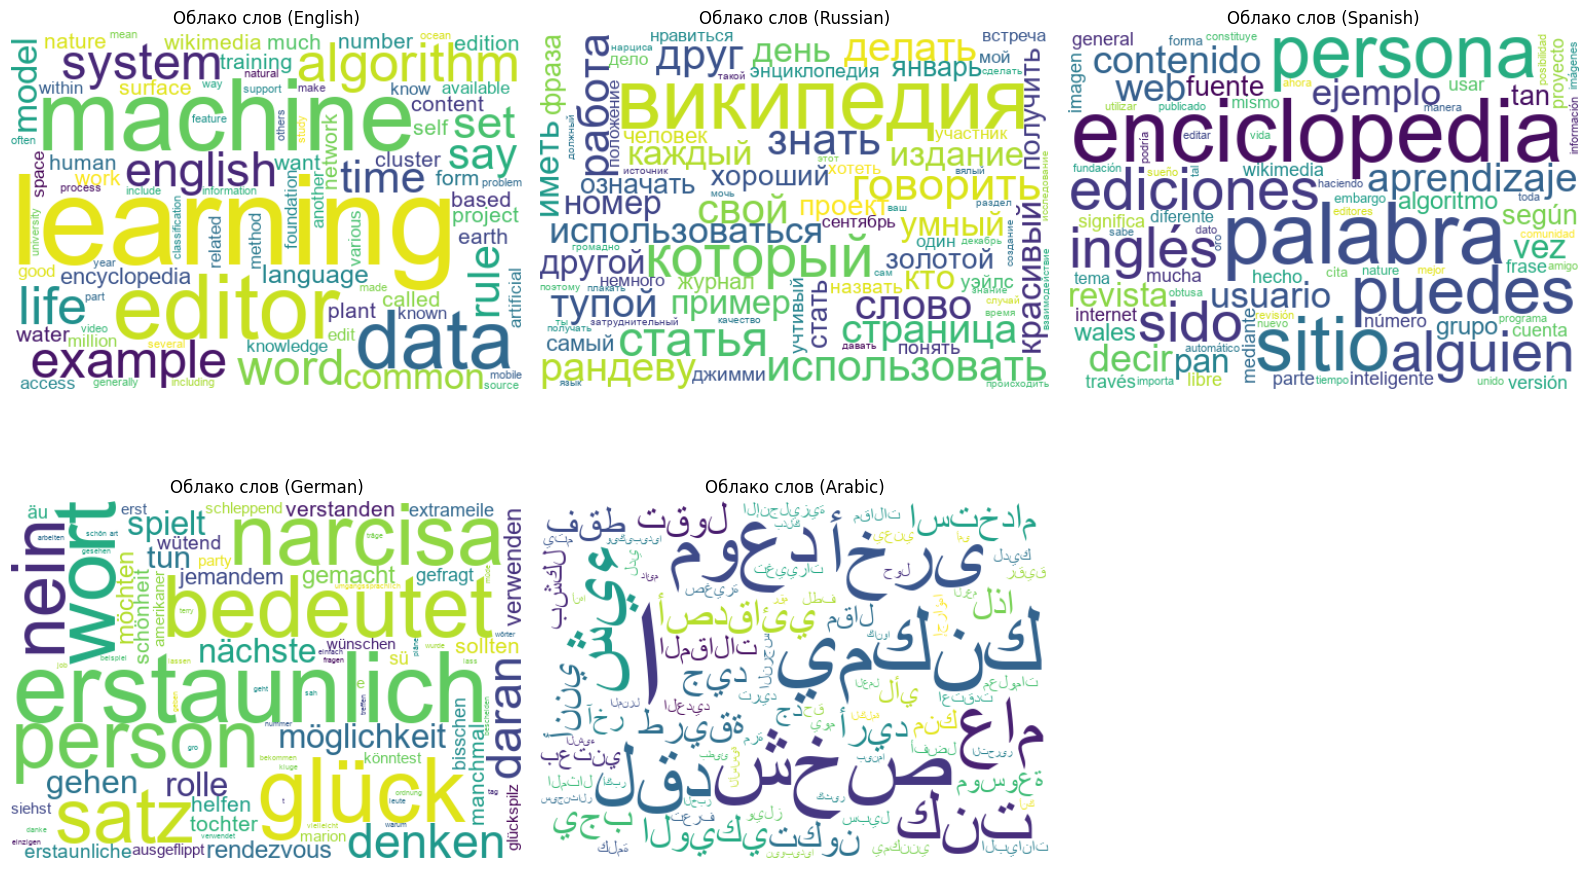

In [12]:
X_train_aug, X_test_aug, y_train_aug, y_test_aug = train_test_split(
    df_augmented['stemmed_text'], df_augmented['Language'], test_size=0.2, random_state=42, stratify=df_augmented['Language']
)

vectorizer_aug = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4), max_features=25000)
X_train_aug_vec = vectorizer_aug.fit_transform(X_train_aug)
X_test_aug_vec = vectorizer_aug.transform(X_test_aug)

best_aug_model = CalibratedClassifierCV(estimator=LinearSVC(random_state=42))
print("Обучение финальной лучшей модели (Linear SVC) на полностью расширенном датасете...")
best_aug_model.fit(X_train_aug_vec, y_train_aug)
final_preds = best_aug_model.predict(X_test_aug_vec)
final_acc = accuracy_score(y_test_aug, final_preds)
print(f"Точность финальной модели: {final_acc:.4f}")

best_aug_name = 'Linear SVC'
aug_results = {best_aug_name: {'preds': final_preds}}

print("--- Краткий анализ финального датасета ---")
lang_counts_aug = df_augmented['Language'].value_counts()
print("Language Distribution:")
print(lang_counts_aug.head(10))

plt.figure(figsize=(12, 6))
sns.barplot(x=lang_counts_aug.index, y=lang_counts_aug.values, hue=lang_counts_aug.index, palette='magma', legend=False)
plt.title("Augmented Dataset Language Distribution (Active Learning)")
plt.xlabel("Language")
plt.ylabel("Row Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('dataset_stats_augmented.png', dpi=300)
plt.show()

cm_aug = confusion_matrix(y_test_aug, aug_results[best_aug_name]['preds'], labels=sorted(unique_languages))
plt.figure(figsize=(14, 12))
sns.heatmap(cm_aug, annot=True, fmt='d', xticklabels=sorted(unique_languages), yticklabels=sorted(unique_languages), cmap='Purples')
plt.title(f"Матрица ошибок (Active Learning) - {best_aug_name}")
plt.xlabel("Спрогнозированный язык")
plt.ylabel("Фактический язык")
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

final_pipeline = Pipeline([
    ('vectorizer', vectorizer_aug),
    ('classifier', best_aug_model)
])

with open('best_model.pkl', 'wb') as f:
    pickle.dump(final_pipeline, f)
print("Финальная модель успешно сохранена в best_model.pkl!")

print("Обновление облака слов...")
plt.figure(figsize=(16, 10))
for i, lang in enumerate(['English', 'Russian', 'Spanish', 'German', 'Arabic']):
    lang_text = ' '.join(df_augmented[df_augmented['Language'] == lang]['clean_text'].astype(str))
    if lang_text.strip():
        wc = WordCloud(font_path='arial.ttf', width=500, height=350, background_color='white', max_words=80, collocations=False).generate(lang_text)
        plt.subplot(2, 3, i+1)
        plt.imshow(wc, interpolation='bilinear')
        plt.title(f"Облако слов ({lang})")
        plt.axis('off')
plt.tight_layout()
plt.savefig('wordclouds.png', dpi=300)
plt.show()
